# Import Libraries 

In [44]:
import keras
import tensorflow as tf
import numpy as np
import cv2
from PIL  import Image

# Get The Date

In [45]:
data_dir_train="intel/seg_train/seg_train"
data_dir_test="intel/seg_test/seg_test"
batch_size=32
img_height=150
img_width=150

In [46]:
train_ds= keras.utils.image_dataset_from_directory(
    data_dir_train,
    validation_split=0.2,
    subset="training",
    seed=9090,
    image_size=(img_height,img_width),
    batch_size=batch_size,
    label_mode="categorical"
)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.


In [47]:
len(train_ds)*32

11232

In [48]:
validation_ds=keras.utils.image_dataset_from_directory(
    data_dir_train,
    subset="validation",
    seed=9090,
    validation_split=0.2,
    image_size=(img_height,img_width),
    batch_size=batch_size,
    label_mode="categorical"
    
)

Found 14034 files belonging to 6 classes.
Using 2806 files for validation.


In [49]:
class_names=train_ds.class_names

# Get Overview

In [50]:
for images_batch,labels_batch in train_ds.take(1):
    print(labels_batch)
    print(images_batch)

tf.Tensor(
[[0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]], shape=(32, 6), dtype=float32)
tf.Tensor(
[[[[161. 244. 136.]
   [143. 212. 121.]
   [115. 150.  96.]
   ...
   [186. 255. 157.]
   [ 87. 190.  49.]
   [ 65. 182.  23.]]

  [[ 56. 134.  32.]
   [133. 199. 111.]
   [105. 146.  88.]
   ...
   [151. 237. 128.]
   [ 78. 175.  44.]
   [129. 232.  91.]]

  [[ 69. 138.  4

In [51]:
img_test=np.array(images_batch[0]).astype(np.uint8)

In [52]:
import pandas as pd 
import matplotlib.pyplot as plt

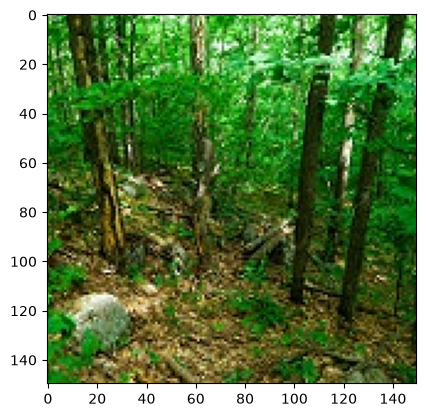

In [53]:
plt.imshow(img_test)

In [54]:

labels_counts=[]

for images,labels in train_ds:
    labels_counts.extend(labels)
    


    

In [56]:
labels_counts

[<tf.Tensor: shape=(6,), dtype=float32, numpy=array([1., 0., 0., 0., 0., 0.], dtype=float32)>,
 <tf.Tensor: shape=(6,), dtype=float32, numpy=array([1., 0., 0., 0., 0., 0.], dtype=float32)>,
 <tf.Tensor: shape=(6,), dtype=float32, numpy=array([0., 0., 0., 0., 0., 1.], dtype=float32)>,
 <tf.Tensor: shape=(6,), dtype=float32, numpy=array([1., 0., 0., 0., 0., 0.], dtype=float32)>,
 <tf.Tensor: shape=(6,), dtype=float32, numpy=array([0., 0., 1., 0., 0., 0.], dtype=float32)>,
 <tf.Tensor: shape=(6,), dtype=float32, numpy=array([0., 0., 0., 1., 0., 0.], dtype=float32)>,
 <tf.Tensor: shape=(6,), dtype=float32, numpy=array([0., 0., 0., 0., 0., 1.], dtype=float32)>,
 <tf.Tensor: shape=(6,), dtype=float32, numpy=array([0., 1., 0., 0., 0., 0.], dtype=float32)>,
 <tf.Tensor: shape=(6,), dtype=float32, numpy=array([0., 0., 0., 0., 0., 1.], dtype=float32)>,
 <tf.Tensor: shape=(6,), dtype=float32, numpy=array([0., 0., 1., 0., 0., 0.], dtype=float32)>,
 <tf.Tensor: shape=(6,), dtype=float32, numpy=arra

In [57]:
# labels_df=pd.DataFrame({
#     "labels":map(int,labels_counts)
# })
    
# labels_df

In [ ]:
# labels_df.value_counts()

labels
3         2007
2         1936
5         1879
4         1851
1         1829
0         1726
Name: count, dtype: int64

- data is quiet balanced

# Layers Of Augmentation

In [58]:
data_aug=keras.models.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
    keras.layers.RandomBrightness(0.2)
])

In [59]:
model_intel=keras.models.Sequential([
    keras.layers.Conv2D(32,(3,3),activation="relu"),
    
    keras.layers.Conv2D(64,(3,3),activation="relu"),
    
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(128,(3,3),activation="relu"),
    
    keras.layers.Flatten(),
    keras.layers.Dense(128),
    keras.layers.Dense(64),
    keras.layers.Dense(6,activation="softmax")]
    
    
)

In [60]:
from keras import metrics
from keras.callbacks import EarlyStopping

f1=metrics.F1Score(average="macro",name="f1_score")

early_stop=EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

In [61]:
model_intel.compile(
    optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy",f1]
)

In [62]:
history=model_intel.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20


c:\Users\Access\Desktop\intel_data\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


108/351 ━━━━━━━━━━━━━━━━━━━━ 13:21 3s/step - accuracy: 0.2266 - f1_score: 0.1792 - loss: 390.2663

KeyboardInterrupt: 